# 01 — Exploratory Data Analysis (EDA)

> **Project**: CS5483 ChallengeData #163 — Predict Parking Violations  
> **Data Source**: THESi curbside parking system, Thessaloniki, Greece  
> **Training Set**: ~6.07M rows, 10 features, target variable `invalid_ratio` (0–1)  
> **Evaluation Metric**: Spearman correlation coefficient  

Goals of this notebook:
1. Understand data distributions and feature characteristics
2. Discover key patterns (spatial, temporal, sample-size vs. noise)
3. Produce 6–8 reusable figures for the report and video

In [1]:
# === Setup ===
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Font settings (macOS)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

# Common style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)

print('Libraries loaded ✓')

Libraries loaded ✓


## Step 1: Data Loading (Memory-Efficient)

Specify dtypes to downcast float64 → float32 and int64 → int8/int32, reducing memory from ~2.4 GB to ~200 MB.

In [2]:
DATA_DIR = '../163-Predict parking violations/'

# Specify dtypes to reduce memory usage
dtype_dict = {
    'total_count': 'int32',
    'longitude_scaled': 'float32',
    'latitude_scaled': 'float32',
    'Precipitations': 'float32',
    'HauteurNeige': 'float32',
    'Temperature': 'float32',
    'ForceVent': 'float32',
    'day_of_week': 'int8',
    'month_of_year': 'int8',
    'hour': 'int8',
}

x_train = pd.read_csv(f'{DATA_DIR}x_train_final_asAbTs5.csv', dtype=dtype_dict, index_col=0)
y_train = pd.read_csv(f'{DATA_DIR}y_train_final_YYyFil7.csv', index_col=0)
x_test = pd.read_csv(f'{DATA_DIR}x_test_final_fIrnA7Q.csv', dtype=dtype_dict, index_col=0)

# Merge training features and target
train_df = x_train.copy()
train_df['invalid_ratio'] = y_train['invalid_ratio'].astype('float32')

print(f'Training set: {train_df.shape[0]:,} rows, {train_df.shape[1]} columns')
print(f'Test set: {x_test.shape[0]:,} rows, {x_test.shape[1]} columns')
print(f'Memory usage: train_df = {train_df.memory_usage(deep=True).sum() / 1024**2:.0f} MB')

Training set: 6,076,546 rows, 11 columns
Test set: 2,028,750 rows, 10 columns
Memory usage: train_df = 203 MB


## Step 2: Basic Statistics

In [3]:
# Data types and non-null counts
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6076546 entries, 0 to 6076545
Data columns (total 11 columns):
 #   Column            Dtype  
---  ------            -----  
 0   total_count       int32  
 1   longitude_scaled  float32
 2   latitude_scaled   float32
 3   Precipitations    float32
 4   HauteurNeige      float32
 5   Temperature       float32
 6   ForceVent         float32
 7   day_of_week       int8   
 8   month_of_year     int8   
 9   hour              int8   
 10  invalid_ratio     float32
dtypes: float32(7), int32(1), int8(3)
memory usage: 202.8 MB


In [4]:
# Descriptive statistics
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_count,6076546.0,8.686006,11.635925,1.0,1.000000,4.000000,11.000000,1669.000000
longitude_scaled,6076546.0,0.998848,0.000664,0.0,0.998586,0.998858,0.999117,0.999799
latitude_scaled,6076546.0,0.996109,0.008066,0.0,0.995974,0.996152,0.996363,0.999842
Precipitations,6076546.0,0.113206,0.572041,0.0,0.000000,0.000000,0.000000,23.600000
HauteurNeige,5912530.0,0.004203,0.064698,0.0,0.000000,0.000000,0.000000,1.000000
Temperature,6076546.0,15.201101,6.935351,-3.6,10.500000,14.500000,20.100000,35.299999
ForceVent,6070464.0,3.356024,1.486184,0.0,2.200000,3.200000,4.200000,10.500000
day_of_week,6076546.0,3.531196,1.706587,1.0,2.000000,4.000000,5.000000,6.000000
month_of_year,6076546.0,6.562192,3.463648,1.0,4.000000,7.000000,10.000000,12.000000
hour,6076546.0,12.257940,3.177690,6.0,9.000000,12.000000,15.000000,19.000000


In [5]:
# Missing value check
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
missing_info = pd.DataFrame({'Missing Count': missing, 'Missing Rate (%)': missing_pct})
print(missing_info[missing_info['Missing Count'] > 0])
print(f'\nTotal rows: {len(train_df):,}')
print(f'Conclusion: Very few missing values — HauteurNeige {missing_pct["HauteurNeige"]:.2f}%, ForceVent {missing_pct["ForceVent"]:.2f}%')

              Missing Count  Missing Rate (%)
HauteurNeige         164016               2.7
ForceVent              6082               0.1

Total rows: 6,076,546
Conclusion: Very few missing values — HauteurNeige 2.70%, ForceVent 0.10%


## Step 3: Target Variable Distribution ⭐

`invalid_ratio` exhibits a U-shaped distribution — a large proportion of samples are concentrated near 0 and 1.  
Root cause: when `total_count=1`, the violation rate can only be 0 or 1 (binary noise).

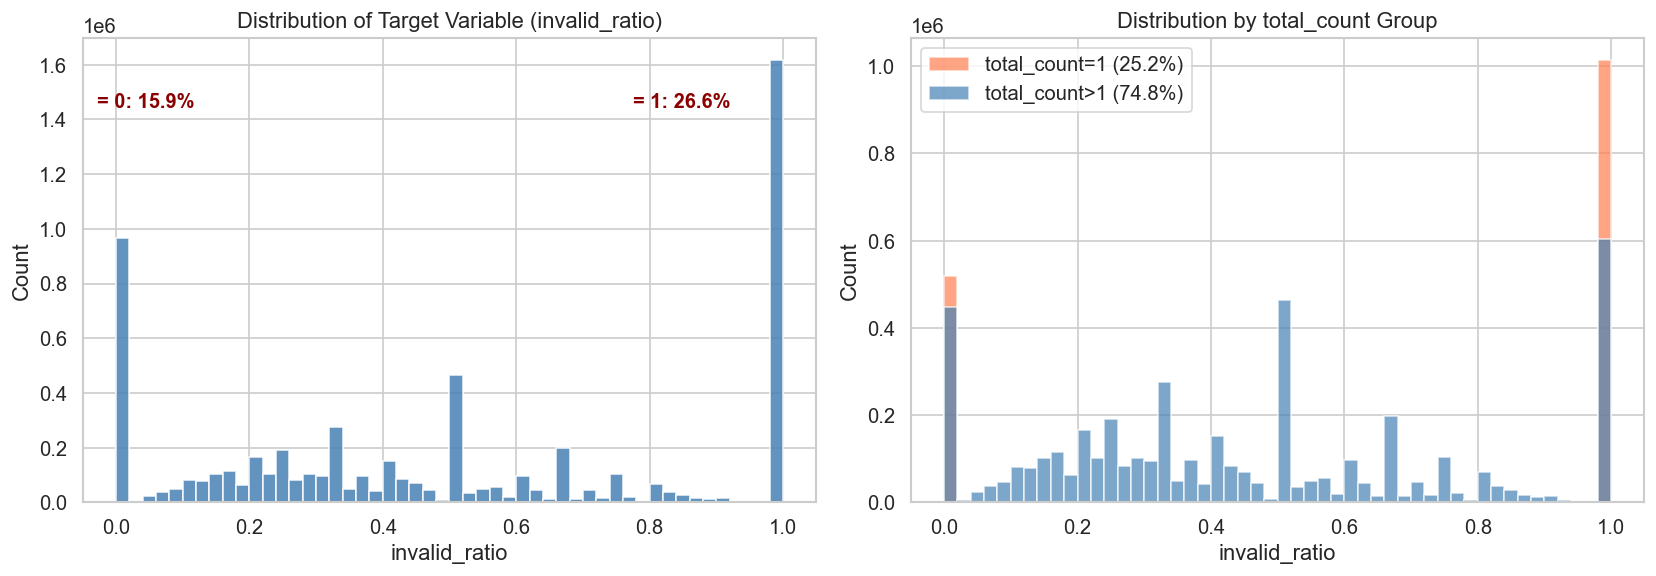

Proportion of invalid_ratio=0: 15.90%
Proportion of invalid_ratio=1: 26.62%
Proportion of total_count=1 samples: 25.22%


In [6]:
# === Figure 1: Target variable invalid_ratio distribution ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall distribution histogram
ax = axes[0]
ax.hist(train_df['invalid_ratio'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('invalid_ratio')
ax.set_ylabel('Count')
ax.set_title('Distribution of Target Variable (invalid_ratio)')

# Annotate the proportion of =0 and =1
n_total = len(train_df)
pct_zero = (train_df['invalid_ratio'] == 0).sum() / n_total * 100
pct_one = (train_df['invalid_ratio'] == 1).sum() / n_total * 100
ax.annotate(f'= 0: {pct_zero:.1f}%', xy=(0.02, 0.85), xycoords='axes fraction',
            fontsize=12, color='darkred', fontweight='bold')
ax.annotate(f'= 1: {pct_one:.1f}%', xy=(0.75, 0.85), xycoords='axes fraction',
            fontsize=12, color='darkred', fontweight='bold')

# Right: breakdown by total_count — reveals the root cause of the U-shape
ax = axes[1]
mask_tc1 = train_df['total_count'] == 1
ax.hist(train_df.loc[mask_tc1, 'invalid_ratio'].dropna(), bins=50,
        alpha=0.7, label=f'total_count=1 ({mask_tc1.sum()/n_total*100:.1f}%)', color='coral')
ax.hist(train_df.loc[~mask_tc1, 'invalid_ratio'].dropna(), bins=50,
        alpha=0.7, label=f'total_count>1 ({(~mask_tc1).sum()/n_total*100:.1f}%)', color='steelblue')
ax.set_xlabel('invalid_ratio')
ax.set_ylabel('Count')
ax.set_title('Distribution by total_count Group')
ax.legend()

plt.tight_layout()
plt.savefig('../docs/figures/fig1_target_distribution.png', bbox_inches='tight')
plt.show()

print(f'Proportion of invalid_ratio=0: {pct_zero:.2f}%')
print(f'Proportion of invalid_ratio=1: {pct_one:.2f}%')
print(f'Proportion of total_count=1 samples: {mask_tc1.sum()/n_total*100:.2f}%')

## Step 4: Relationship between total_count and Violation Rate ⭐

`total_count` (number of inspections) is the strongest predictor (Spearman ρ ≈ −0.297).  
More inspections → more stable violation rate estimates; `total_count=1` has extreme noise.

Group  Sample Count     Mean      Std   Median
    1       1532442 0.662094 0.472996 1.000000
  2-3       1150241 0.582404 0.382337 0.500000
 4-10       1751905 0.458496 0.294806 0.428571
11-30       1343611 0.354176 0.212836 0.318182
  31+        298347 0.298909 0.170801 0.266667


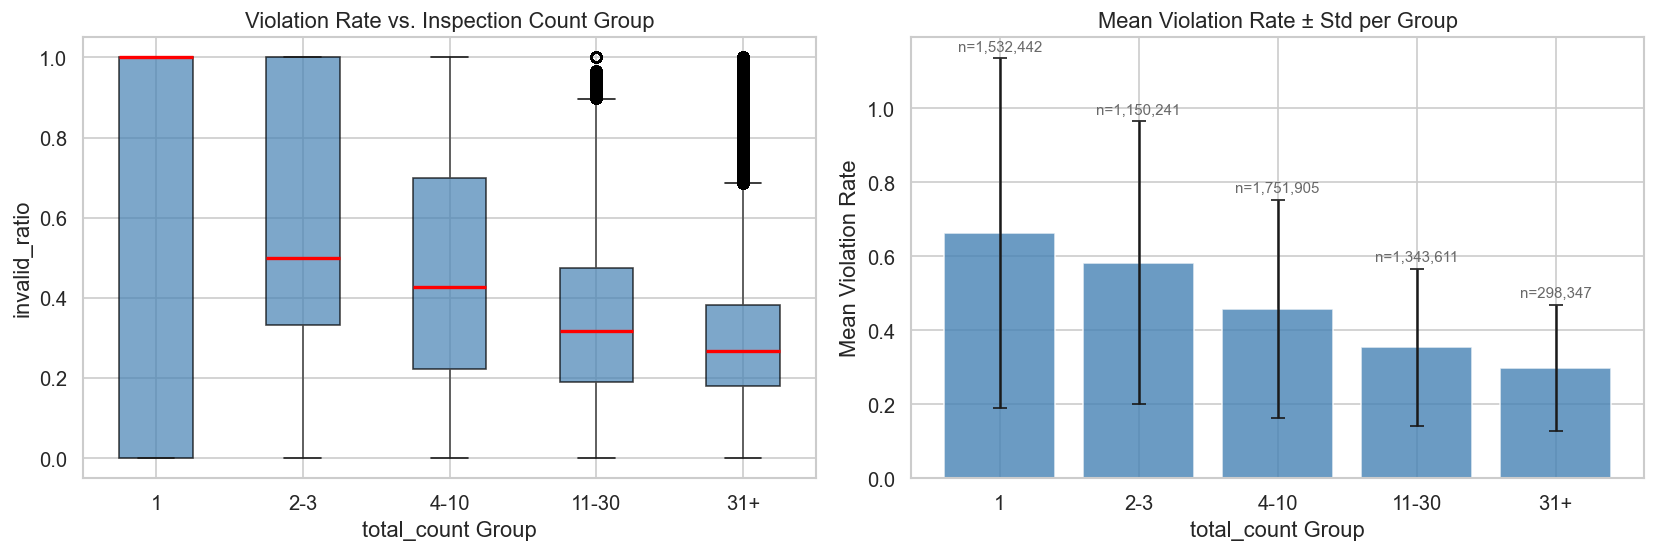

In [7]:
# === Figure 2: total_count vs. violation rate ===
# Bin total_count into groups
bins = [0, 1, 3, 10, 30, np.inf]
labels = ['1', '2-3', '4-10', '11-30', '31+']
train_df['count_group'] = pd.cut(train_df['total_count'], bins=bins, labels=labels)

# Compute per-group statistics
group_stats = train_df.groupby('count_group', observed=True)['invalid_ratio'].agg(
    ['count', 'mean', 'std', 'median']
).reset_index()
group_stats.columns = ['Group', 'Sample Count', 'Mean', 'Std', 'Median']
print(group_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: box plot
ax = axes[0]
train_df.boxplot(column='invalid_ratio', by='count_group', ax=ax,
                 patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
ax.set_xlabel('total_count Group')
ax.set_ylabel('invalid_ratio')
ax.set_title('Violation Rate vs. Inspection Count Group')
fig.suptitle('')  # Remove default pandas title

# Right: mean ± std bar chart
ax = axes[1]
ax.bar(group_stats['Group'], group_stats['Mean'], yerr=group_stats['Std'],
       color='steelblue', alpha=0.8, capsize=4, edgecolor='white')
ax.set_xlabel('total_count Group')
ax.set_ylabel('Mean Violation Rate')
ax.set_title('Mean Violation Rate ± Std per Group')

# Annotate sample counts on bars
for i, row in group_stats.iterrows():
    ax.text(i, row['Mean'] + row['Std'] + 0.02, f"n={row['Sample Count']:,}",
            ha='center', fontsize=9, color='dimgray')

plt.tight_layout()
plt.savefig('../docs/figures/fig2_totalcount_vs_violation.png', bbox_inches='tight')
plt.show()

# Clean up temporary column
train_df.drop(columns=['count_group'], inplace=True)

## Step 5: Feature Distributions

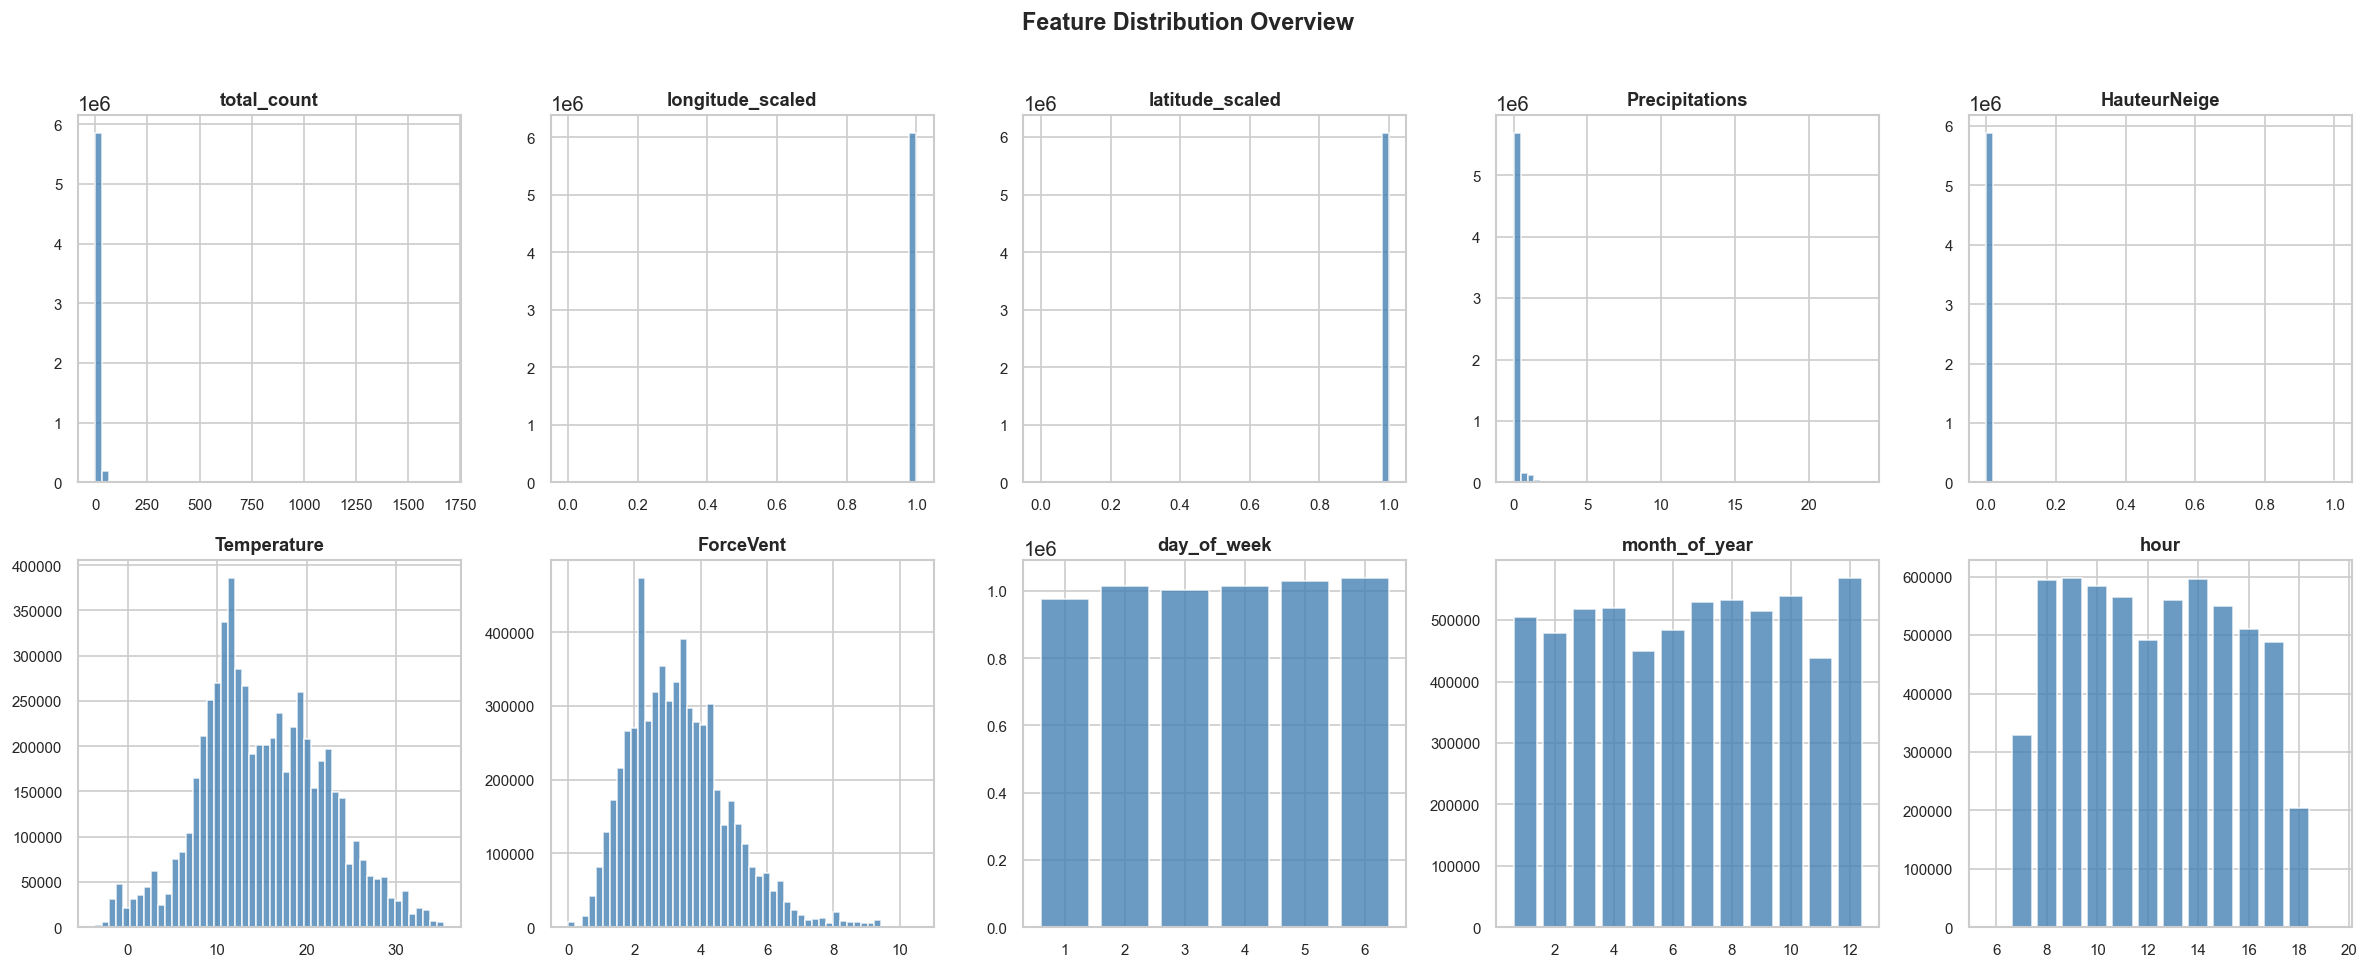

In [8]:
# === Figure 3: Distribution of all 10 raw features (2×5 subplots) ===
features = ['total_count', 'longitude_scaled', 'latitude_scaled',
            'Precipitations', 'HauteurNeige', 'Temperature',
            'ForceVent', 'day_of_week', 'month_of_year', 'hour']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    data = train_df[feat].dropna()

    # Use bar chart for discrete features, histogram for continuous
    if feat in ['day_of_week', 'month_of_year', 'hour']:
        counts = data.value_counts().sort_index()
        ax.bar(counts.index, counts.values, color='steelblue', alpha=0.8, edgecolor='white')
    else:
        ax.hist(data, bins=50, color='steelblue', alpha=0.8, edgecolor='white')

    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=9)

plt.suptitle('Feature Distribution Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../docs/figures/fig3_feature_distributions.png', bbox_inches='tight')
plt.show()

## Step 6: Spearman Correlation Analysis

The evaluation metric for this project is the Spearman correlation coefficient (measures rank-order consistency), so we use Spearman rather than Pearson.

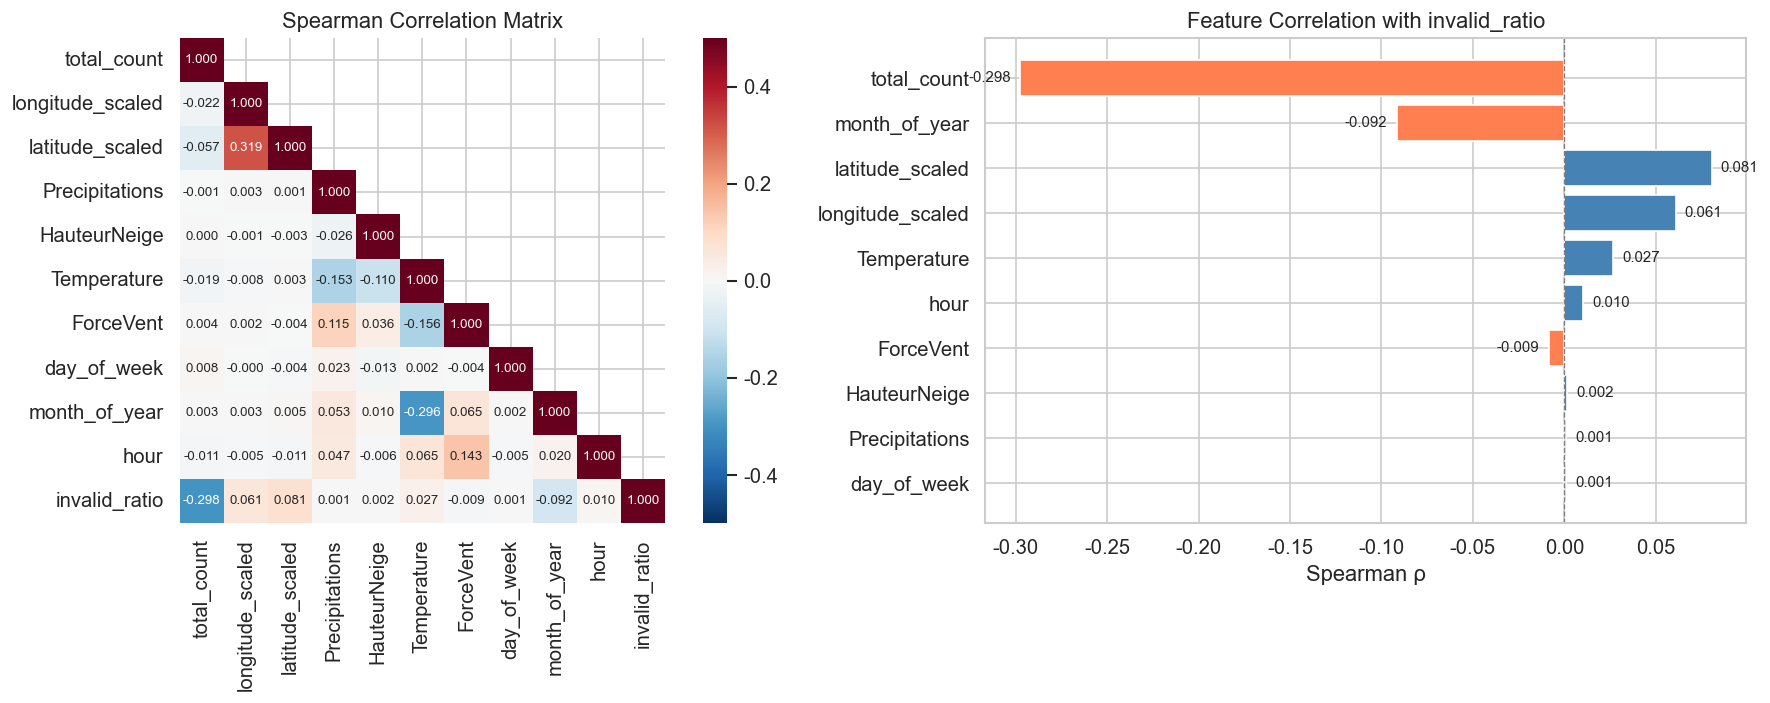

In [9]:
# === Figure 4: Spearman correlation coefficients ===
# Subsample for speed (full 6M-row Spearman corr matrix is slow)
sample_df = train_df.sample(n=500_000, random_state=SEED)
spearman_corr = sample_df[features + ['invalid_ratio']].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: full heatmap
ax = axes[0]
mask = np.triu(np.ones_like(spearman_corr, dtype=bool), k=1)  # Upper-triangle mask
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-0.5, vmax=0.5, square=True, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Spearman Correlation Matrix')

# Right: bar chart of each feature vs. invalid_ratio (sorted by |ρ|)
ax = axes[1]
target_corr = spearman_corr['invalid_ratio'].drop('invalid_ratio').sort_values(key=abs, ascending=True)
colors = ['coral' if v < 0 else 'steelblue' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.set_xlabel('Spearman ρ')
ax.set_title('Feature Correlation with invalid_ratio')
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Annotate values
for i, (feat, val) in enumerate(target_corr.items()):
    ax.text(val + (0.005 if val >= 0 else -0.005), i, f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/figures/fig4_spearman_correlation.png', bbox_inches='tight')
plt.show()

## Step 7: Spatial Violation Rate Distribution ⭐

Coordinates are scaled values (~0.98–1.00). Different areas show significantly different violation rates — this is the core justification for regional Target Encoding.

After filtering outliers: 99.81% of data retained
Longitude range: [0.998274, 0.999799]
Latitude range: [0.995633, 0.999842]


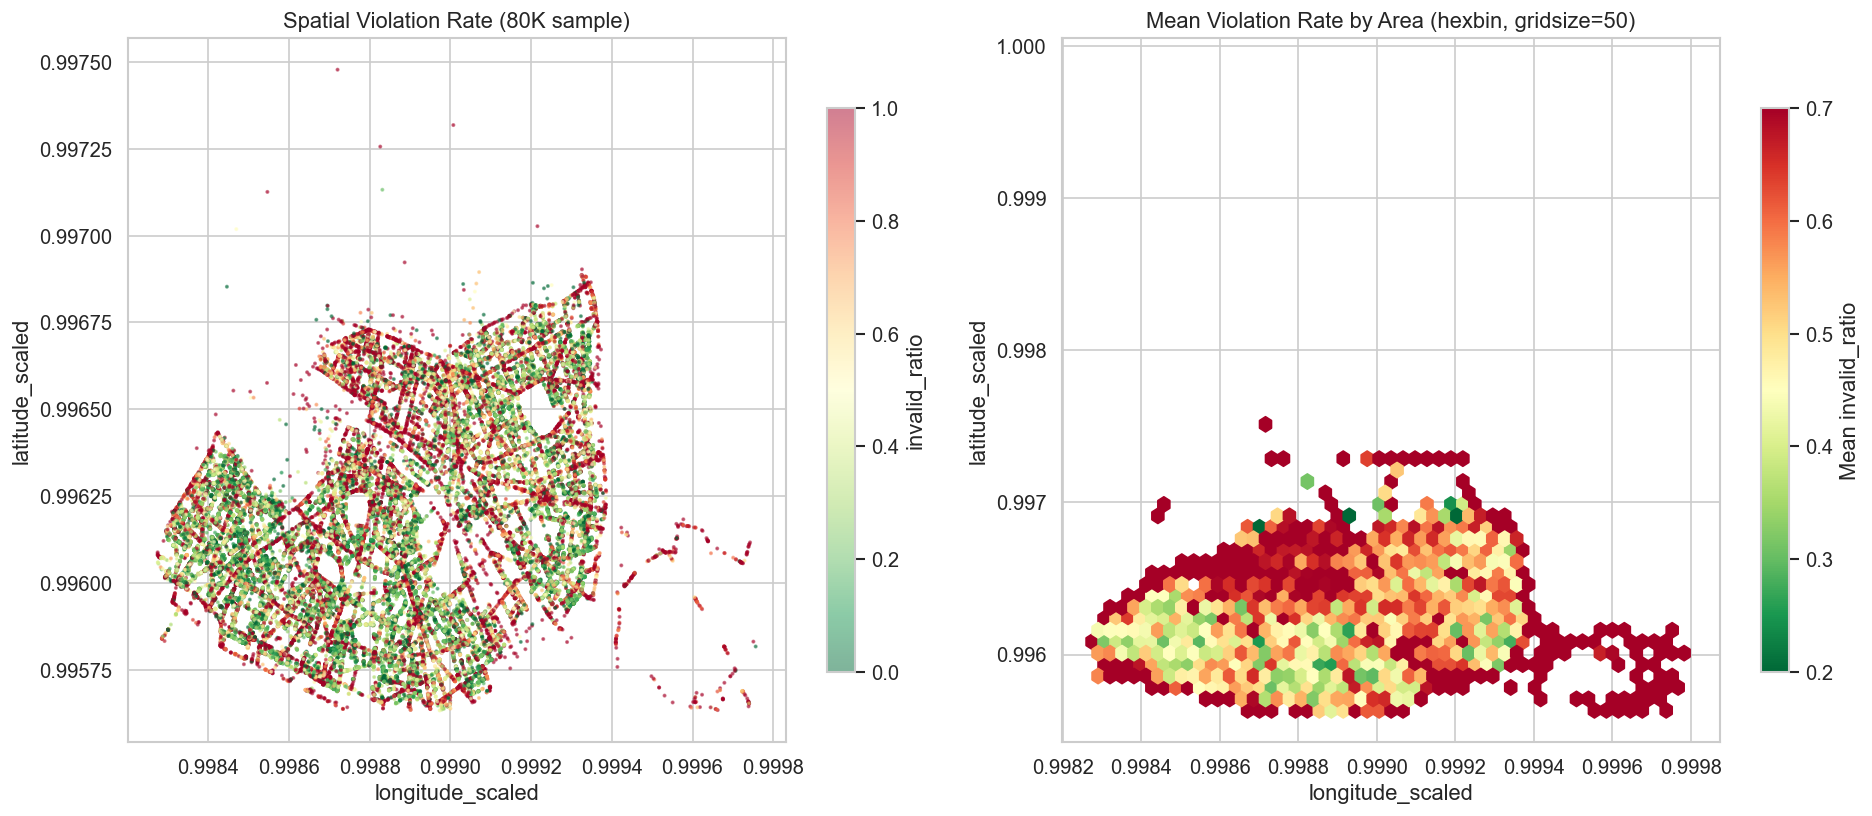

In [10]:
# === Figure 5: Spatial violation rate distribution ===
# Coordinates have a few extreme outliers (min=0); focus on the main data region (>99.9%)
lon_q01 = train_df['longitude_scaled'].quantile(0.001)
lat_q01 = train_df['latitude_scaled'].quantile(0.001)
spatial_mask = (train_df['longitude_scaled'] > lon_q01) & (train_df['latitude_scaled'] > lat_q01)
print(f'After filtering outliers: {spatial_mask.sum()/len(train_df)*100:.2f}% of data retained')
print(f'Longitude range: [{train_df.loc[spatial_mask, "longitude_scaled"].min():.6f}, {train_df.loc[spatial_mask, "longitude_scaled"].max():.6f}]')
print(f'Latitude range: [{train_df.loc[spatial_mask, "latitude_scaled"].min():.6f}, {train_df.loc[spatial_mask, "latitude_scaled"].max():.6f}]')

# Subsample to avoid overplotting
spatial_sample = train_df.loc[spatial_mask].sample(n=80_000, random_state=SEED)
spatial_full = train_df.loc[spatial_mask]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: scatter plot, color = violation rate
ax = axes[0]
sc = ax.scatter(spatial_sample['longitude_scaled'], spatial_sample['latitude_scaled'],
                c=spatial_sample['invalid_ratio'], cmap='RdYlGn_r',
                s=2, alpha=0.5, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='invalid_ratio', shrink=0.8)
ax.set_xlabel('longitude_scaled')
ax.set_ylabel('latitude_scaled')
ax.set_title('Spatial Violation Rate (80K sample)')

# Right: hexbin heatmap — mean violation rate (shows area-level differences more clearly)
ax = axes[1]
hb = ax.hexbin(spatial_full['longitude_scaled'], spatial_full['latitude_scaled'],
               C=spatial_full['invalid_ratio'], gridsize=50,
               reduce_C_function=np.mean, cmap='RdYlGn_r', vmin=0.2, vmax=0.7,
               mincnt=10)  # Require at least 10 samples per hex
plt.colorbar(hb, ax=ax, label='Mean invalid_ratio', shrink=0.8)
ax.set_xlabel('longitude_scaled')
ax.set_ylabel('latitude_scaled')
ax.set_title('Mean Violation Rate by Area (hexbin, gridsize=50)')

plt.tight_layout()
plt.savefig('../docs/figures/fig5_spatial_violation.png', bbox_inches='tight')
plt.show()

## Step 8: Temporal Patterns ⭐

Mean violation rate trends across three temporal dimensions: hour, day_of_week, and month_of_year.

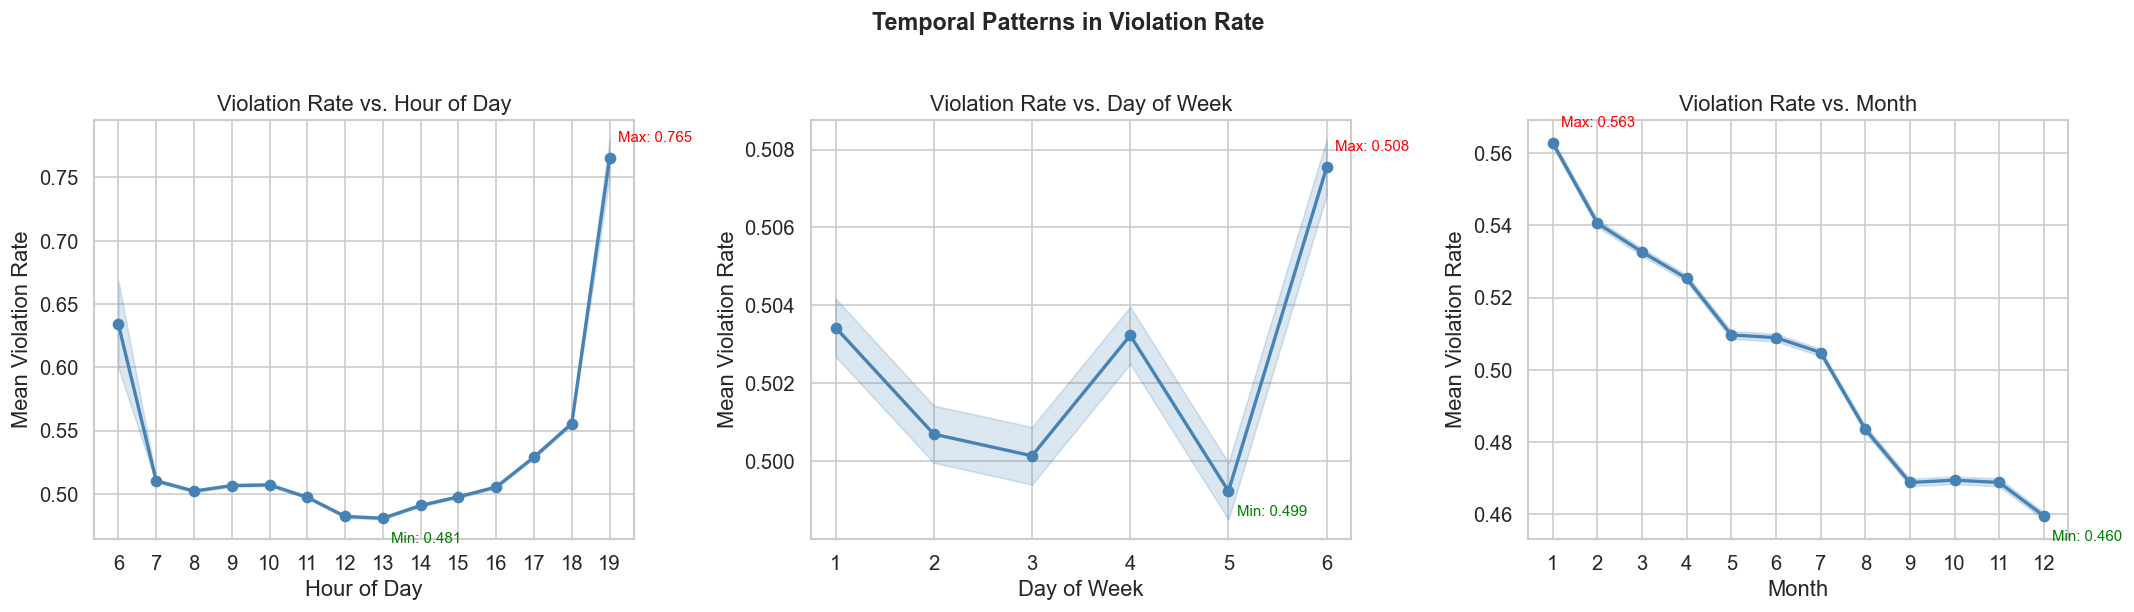

In [11]:
# === Figure 6: Temporal patterns — hour / day_of_week / month_of_year ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

time_features = [
    ('hour', 'Hour of Day', range(6, 20)),
    ('day_of_week', 'Day of Week', range(1, 7)),
    ('month_of_year', 'Month', range(1, 13)),
]

for ax, (feat, label, expected_range) in zip(axes, time_features):
    # Compute mean and standard error
    grouped = train_df.groupby(feat)['invalid_ratio']
    means = grouped.mean()
    sems = grouped.sem()  # Standard error (very narrow CI due to large sample size)

    ax.plot(means.index, means.values, 'o-', color='steelblue', linewidth=2, markersize=6)
    ax.fill_between(means.index, means.values - 2*sems.values, means.values + 2*sems.values,
                    alpha=0.2, color='steelblue')
    ax.set_xlabel(label)
    ax.set_ylabel('Mean Violation Rate')
    ax.set_title(f'Violation Rate vs. {label}')
    ax.set_xticks(list(expected_range))

    # Annotate max and min points
    max_idx = means.idxmax()
    min_idx = means.idxmin()
    ax.annotate(f'Max: {means[max_idx]:.3f}', xy=(max_idx, means[max_idx]),
                xytext=(5, 10), textcoords='offset points', fontsize=9, color='red')
    ax.annotate(f'Min: {means[min_idx]:.3f}', xy=(min_idx, means[min_idx]),
                xytext=(5, -15), textcoords='offset points', fontsize=9, color='green')

plt.suptitle('Temporal Patterns in Violation Rate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/figures/fig6_time_patterns.png', bbox_inches='tight')
plt.show()

## Step 9: Missing Value Visualization

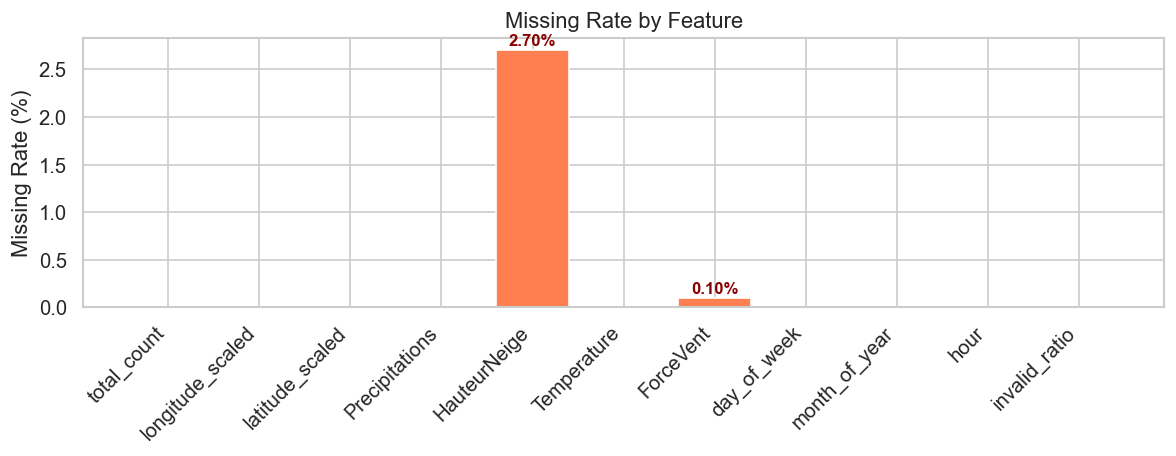

Imputation strategy:
  HauteurNeige (snow depth) → fill with 0 (no snow is a reasonable default)
  ForceVent (wind force) → fill with median (very low missing rate, median is safe)


In [12]:
# === Figure 7: Missing value bar chart ===
fig, ax = plt.subplots(figsize=(10, 4))

missing_pct_all = (train_df.isnull().sum() / len(train_df) * 100)
colors = ['coral' if v > 0 else 'steelblue' for v in missing_pct_all.values]
bars = ax.bar(missing_pct_all.index, missing_pct_all.values, color=colors, edgecolor='white')

ax.set_ylabel('Missing Rate (%)')
ax.set_title('Missing Rate by Feature')
ax.set_xticklabels(missing_pct_all.index, rotation=45, ha='right')

# Annotate features with missing values
for bar, val in zip(bars, missing_pct_all.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.2f}%',
                ha='center', fontsize=10, fontweight='bold', color='darkred')

plt.tight_layout()
plt.savefig('../docs/figures/fig7_missing_values.png', bbox_inches='tight')
plt.show()

print('Imputation strategy:')
print('  HauteurNeige (snow depth) → fill with 0 (no snow is a reasonable default)')
print('  ForceVent (wind force) → fill with median (very low missing rate, median is safe)')

## Key EDA Findings

1. **U-shaped target distribution**: ~15.9% equal 0, ~26.6% equal 1. Root cause: when `total_count=1`, the ratio can only be 0 or 1.
2. **`total_count` is the strongest predictor**: Spearman ρ ≈ −0.298. More inspections → lower and more stable violation rate.
3. **Spatial clustering**: Certain areas have significantly higher violation rates → strong justification for regional Target Encoding.
4. **Temporal periodicity**: Month ρ ≈ −0.091 (lower in summer/higher in winter); hour shows a midday peak pattern.
5. **Weak weather effects individually**: Precipitation / Temperature / Wind Spearman ρ < 0.03 each.
6. **Very few missing values**: Only HauteurNeige (~2.7%) and ForceVent (~0.1%), with clear imputation strategies.

### Implications for Feature Engineering

| Priority | Direction | Expected Gain |
|----------|-----------|---------------|
| **Tier 1** | Regional Target Encoding (grid coordinates → area-level mean violation rate) | High (strong spatial pattern) |
| **Tier 1** | `total_count` transformations (log, binning) | High (strongest predictor) |
| **Tier 1** | Sin/Cos cyclical encoding (hour, dow, month) | Medium (captures periodicity) |
| **Tier 2** | Interaction features (hour × dow, area × time) | Medium |
| **Tier 3** | Weather window averages, precipitation binarization | Low (weak univariate correlations) |

In [13]:
# Free sample data, keep train_df for potential further use
import gc
del sample_df, spatial_sample, spatial_full
gc.collect()
print(f'Current memory: train_df = {train_df.memory_usage(deep=True).sum() / 1024**2:.0f} MB')

Current memory: train_df = 203 MB
